# Investigating the diffference between the training Session's model (multi animal + implant tracking) and the unified dataset's model (resident tracking - C57) in terms of error from Ground truth labeled frames and the prediction confidence. The frames that are common between both methods were used

In [2]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from pathlib import Path
import deeplabcut as dlc
from deeplabcut.utils import auxiliaryfunctions


Loading DLC 3.0.0rc13...


d:\Anaconda3\envs\DEEPLABCUT\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
trainingSess_model =  r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_DLC_multiAnimal\trainingAggression_trainingSessions_topView-MiguelRocha-2026-02-03\exported-models-pytorch\DL708F~1\DLC_TR~1.PT"
unifiedDt_model = r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topview_DLC_singleAnimal\unifiedDataset_topView_DLC--StefanosStagkourakis&MiguelRocha-2026-07-06\exported-models-pytorch\DLC_UN~1\DLC_UN~1.PT"

trainingSess_shuffle = 2
unifiedDt_shuffle = 3

trainingSess_configPath = r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_DLC_multiAnimal\trainingAggression_trainingSessions_topView-MiguelRocha-2026-02-03\config.yaml"
unifiedDt_configPath = r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topview_DLC_singleAnimal\unifiedDataset_topView_DLC--StefanosStagkourakis&MiguelRocha-2026-07-06\config.yaml"

trainingSess_cfg = auxiliaryfunctions.read_config(trainingSess_configPath)
unifiedDt_cfg = auxiliaryfunctions.read_config(unifiedDt_configPath)

### Loading the images that were part of the training/testing set of both models

In [4]:
labeledDataPath = Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topview_DLC_singleAnimal\unifiedDataset_topView_DLC--StefanosStagkourakis&MiguelRocha-2026-07-06\labeled-data")
labeledFrames = [f for f in labeledDataPath.rglob("*topView_comp/*.png")]
print(f"N of common frames: {len(labeledFrames)}")

N of common frames: 889


In [5]:
session_ids = {
    Path(video).stem
    for video in unifiedDt_cfg["video_sets"]
}

commonLabeledFrames = [
    str(frame)
    for frame in labeledFrames
    if Path(frame).parent.name in session_ids
]

print("Number of common Frames: ", len(commonLabeledFrames))

Number of common Frames:  461


In [ ]:
import os, shutil
dest = r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\modelConfidenceCalibration_DLC"

for f in commonLabeledFrames:
    parent = os.path.basename(os.path.dirname(f))                 # video-folder name
    shutil.copy2(f, os.path.join(dest, f"{parent}_{os.path.basename(f)}"))

In [83]:
dlc.analyze_time_lapse_frames?

Signature:
dlc.analyze_time_lapse_frames(
    config: 'str',
    directory: 'str',
    frametype: 'str' = '.png',
    shuffle: 'int' = 1,
    trainingsetindex: 'int' = 0,
    gputouse: 'int | None' = None,
    device: 'str | None' = None,
    save_as_csv: 'bool' = False,
    modelprefix: 'str' = '',
    engine: 'Engine | None' = None,
)
Docstring:
Analyzed all images (of type = frametype) in a folder and stores the output in one file.

You can crop the frames (before analysis), by changing 'cropping'=True and setting
'x1','x2','y1','y2' in the config file.

Output: The labels are stored as MultiIndex Pandas Array, which contains the name
of the network, body part name, (x, y) label position in pixels, and the likelihood
for each frame per body part. These arrays are stored in an efficient Hierarchical
Data Format (HDF) in the same directory, where the video is stored. However, if the
flag save_as_csv is set to True, the data can also be exported in comma-separated
values format (.csv),

In [86]:
# In both models, make sure the right iteration is set up.

dlc.analyze_time_lapse_frames(unifiedDt_configPath, 
                              dest, 
                              frametype=".png",
                              shuffle=unifiedDt_shuffle, 
                              save_as_csv=True)


100%|██████████| 461/461 [00:13<00:00, 34.14it/s]


Saving predictions to C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\modelCalibration_DLC\image_predictions_DLC_Resnet101_unifiedDataset_topView_DLCJul6shuffle3_snapshot_best-150.h5
Saving CSV as C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\modelCalibration_DLC\image_predictions_DLC_Resnet101_unifiedDataset_topView_DLCJul6shuffle3_snapshot_best-150.h5


{'C:\\Users\\stagk\\OneDrive\\Desktop\\trainingAggression_MR\\trainingSessions\\modelCalibration_DLC\\mouse1010819_Day07_topView_comp_img13083.png': {'bodyparts': array([[[445.85855   , 223.87694   ,   0.6672093 ],
          [436.50195   , 192.78056   ,   0.9055311 ],
          [466.65915   , 187.30156   ,   0.92839617],
          [452.6353    , 184.33542   ,   0.8714535 ],
          [450.31757   , 170.27377   ,   1.        ],
          [441.87985   , 156.85129   ,   0.8881068 ],
          [425.31625   , 155.75124   ,   0.9094079 ],
          [409.14377   , 158.13863   ,   0.82245326],
          [376.3684    , 154.7533    ,   0.94238853],
          [334.31015   , 137.53946   ,   1.        ]]], dtype=float32)},
 'C:\\Users\\stagk\\OneDrive\\Desktop\\trainingAggression_MR\\trainingSessions\\modelCalibration_DLC\\mouse1010826_Day12_topView_comp_img04987.png': {'bodyparts': array([[[157.63936   , 230.83887   ,   0.7914611 ],
          [158.13239   , 202.8601    ,   0.2519685 ],
          [

In [87]:
dlc.analyze_time_lapse_frames(trainingSess_configPath, 
                              dest, 
                              frametype=".png",
                              shuffle=trainingSess_shuffle, 
                              save_as_csv=True)

  1%|▏         | 6/461 [00:01<02:03,  3.69it/s]d:\Anaconda3\envs\DEEPLABCUT\Lib\site-packages\deeplabcut\pose_estimation_pytorch\data\postprocessor.py:514: RuntimeWarning: invalid value encountered in cast
  heatmap_indices = np.rint(individual_keypoints).astype(int)
100%|██████████| 461/461 [00:19<00:00, 23.19it/s]


Saving predictions to C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\modelCalibration_DLC\image_predictions_DLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-100.h5
Saving CSV as C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\modelCalibration_DLC\image_predictions_DLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-100.h5


{'C:\\Users\\stagk\\OneDrive\\Desktop\\trainingAggression_MR\\trainingSessions\\modelCalibration_DLC\\mouse1010819_Day07_topView_comp_img13083.png': {'bodyparts': array([[[ 4.51825e+02,  2.26102e+02,  9.98000e-01, -1.00000e+00,
            2.62840e-01],
          [ 4.40958e+02,  1.93080e+02,  9.99000e-01, -1.00000e+00,
            2.62840e-01],
          [ 4.68169e+02,  1.89765e+02,  9.89000e-01, -1.00000e+00,
            2.62840e-01],
          [ 4.54870e+02,  1.84990e+02,  9.48000e-01, -1.00000e+00,
            2.62840e-01],
          [ 4.46201e+02,  1.71667e+02,  9.90000e-01, -1.00000e+00,
            2.62840e-01],
          [ 4.40445e+02,  1.60852e+02,  9.92000e-01, -1.00000e+00,
            2.62840e-01],
          [ 4.23441e+02,  1.57116e+02,  9.97000e-01, -1.00000e+00,
            2.62840e-01],
          [ 4.08830e+02,  1.57683e+02,  9.99000e-01, -1.00000e+00,
            2.62840e-01],
          [ 3.75055e+02,  1.53422e+02,  9.99000e-01, -1.00000e+00,
            2.62840e-01],
  

C:\Users\stagk\AppData\Local\Temp\ipykernel_26212\943167968.py:57: RuntimeWarning: invalid value encountered in log10
  xA, yA = np.log10(cA.ravel()+EPS), np.log10(errA_n.ravel()+EPS); mA = np.isfinite(xA)&np.isfinite(yA)


,bodypart,errA_%body,errB_%body,confA,confB,dConf
0,nose,6.639,2.734,0.000,0.197,-0.059
1,rightEar,6.148,2.518,0.997,0.877,0.107
2,leftEar,6.292,2.675,0.998,0.886,0.102
3,neckBase,6.582,2.670,0.913,0.729,0.123
4,betNeckBaseAndMidPoint,6.794,2.529,0.997,0.897,0.093
5,midPoint,6.742,2.467,0.997,0.885,0.109
6,betMidPointAndTailBase,6.036,2.240,0.998,0.904,0.093
7,tailBase,4.804,2.050,0.999,0.917,0.078
8,tailMid,5.916,2.319,0.997,0.908,0.081
9,tailTip,6.401,2.925,0.995,0.926,0.056


median error  trainingSess 6.2%body  |  unifiedDt 2.5%body
calibration slope/int  trainingSess=(-0.92,-1.23)  unifiedDt=(-0.88,-1.65)


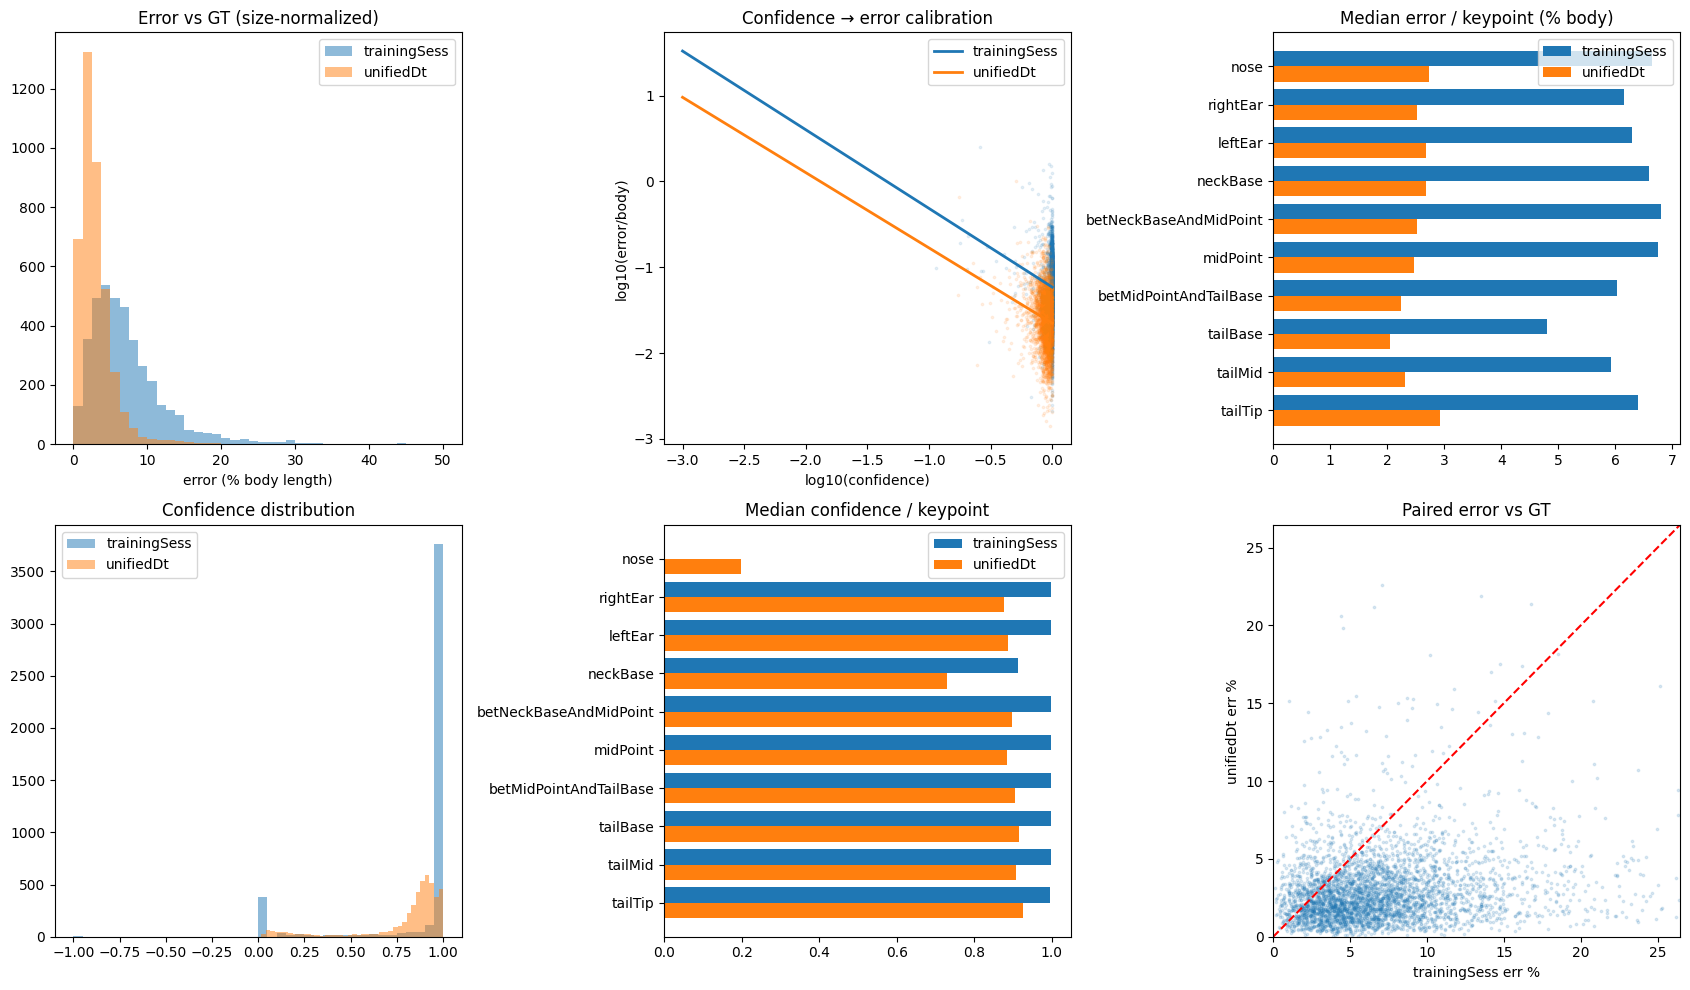

'\n# ---- overlays: GT (green +) vs trainingSess (○) vs unifiedDt (×) ----\noverlay_dir = os.path.join(dest, "overlay_withGT"); os.makedirs(overlay_dir, exist_ok=True)\nfor j, nm in enumerate(names):\n    f = name_to_frame.get(nm)\n    if f is None: continue\n    plt.figure(figsize=(7,7)); plt.imshow(imageio.imread(os.path.join(dest, nm)))\n    for x,y,c in A[j]:\n        if c>=PCUTOFF: plt.scatter(x,y,s=70,marker="o",facecolors="none",edgecolors="C0",linewidths=1.5)\n    for x,y,c in B[j]:\n        if c>=PCUTOFF: plt.scatter(x,y,s=70,marker="x",color="C1")\n    plt.scatter(GT[j,:,0], GT[j,:,1], s=70, marker="+", color="lime")\n    plt.title("+ GT   ○ trainingSess   × unifiedDt"); plt.axis("off")\n    plt.savefig(os.path.join(overlay_dir, nm), dpi=100, bbox_inches="tight"); plt.close()\nprint("overlays saved to", overlay_dir)\n'

In [7]:
import glob
import imageio.v3
import os
IND_A, IND_B = "Resident", "animal"       # resident individual in each PREDICTION model
PCUTOFF, EPS = 0.65, 1e-3
# commonLabeledFrames must still be defined (original frame paths)

trainingSess_h5 = r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\modelConfidenceCalibration_DLC\image_predictions_DLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-100.h5"
unifiedDt_h5    = r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\modelConfidenceCalibration_DLC\image_predictions_DLC_Resnet101_unifiedDataset_topView_DLCJul6shuffle3_snapshot_best-150.h5"

# ---- predictions (resident) ----
dfA = pd.read_hdf(trainingSess_h5).droplevel("scorer", axis=1).xs(IND_A, axis=1, level="individuals")
dfB = pd.read_hdf(unifiedDt_h5).droplevel("scorer", axis=1)
if "individuals" in (dfB.columns.names or []):
    dfB = dfB.xs(IND_B, axis=1, level="individuals")
dfB = dfB.reindex(dfA.index)
bps = [b for b in dict.fromkeys(dfA.columns.get_level_values("bodyparts"))
       if b in set(dfB.columns.get_level_values("bodyparts"))]
A = np.stack([dfA[b][["x","y","likelihood"]].to_numpy(float) for b in bps], 1)
B = np.stack([dfB[b][["x","y","likelihood"]].to_numpy(float) for b in bps], 1)
xyA, cA = A[:,:,:2], A[:,:,2]; xyB, cB = B[:,:,:2], B[:,:,2]
names = [os.path.basename(str(n)) for n in dfA.index]

# ---- ground truth (resident) per frame + per-frame body size ----
name_to_frame = {f"{os.path.basename(os.path.dirname(f))}_{os.path.basename(f)}": f for f in commonLabeledFrames}
cd_cache = {}
GT = np.full((len(names), len(bps), 2), np.nan); BS = np.full(len(names), np.nan)
for j, nm in enumerate(names):
    f = name_to_frame.get(nm)
    if f is None: continue
    pdir = os.path.dirname(f)
    if pdir not in cd_cache:
        h5 = glob.glob(os.path.join(pdir, "CollectedData*.h5"))[0]
        g = pd.read_hdf(h5)
        if "scorer" in (g.columns.names or []):
            g = g.droplevel("scorer", axis=1)
        if "individuals" in (g.columns.names or []):          # multi-animal GT -> pick resident
            inds = list(dict.fromkeys(g.columns.get_level_values("individuals")))
            pick = (next((x for x in inds if x.lower() == "resident"), None)
                    or next((x for x in inds if x.lower() == "animal"), None)
                    or next((x for x in inds if x.lower() != "single"), inds[0]))
            g = g.xs(pick, axis=1, level="individuals")
        g = g.copy()                                          # else: already single-animal, use as-is
        g.index = [os.path.basename(ix if isinstance(ix, str) else ix[-1]) for ix in g.index]
        cd_cache[pdir] = g
    g = cd_cache[pdir]; base = os.path.basename(f)
    if base not in g.index: continue
    gxy = np.array([[g.loc[base, (b, "x")], g.loc[base, (b, "y")]] for b in bps], float)
    GT[j] = gxy
    c = np.nanmean(gxy, 0); BS[j] = np.nanmean(np.linalg.norm(gxy - c, axis=1))   # body-size ruler

# ---- errors vs GT, absolute (px) and size-normalized (% body length) ----
errA = np.linalg.norm(xyA - GT, axis=2); errB = np.linalg.norm(xyB - GT, axis=2)
errA_n = errA / BS[:, None];             errB_n = errB / BS[:, None]

# ---- per-model calibration: confidence -> size-normalized error ----
xA, yA = np.log10(cA.ravel()+EPS), np.log10(errA_n.ravel()+EPS); mA = np.isfinite(xA)&np.isfinite(yA)
xB, yB = np.log10(cB.ravel()+EPS), np.log10(errB_n.ravel()+EPS); mB = np.isfinite(xB)&np.isfinite(yB)
sA, iA = np.polyfit(xA[mA], yA[mA], 1); sB, iB = np.polyfit(xB[mB], yB[mB], 1)

# ---- per-keypoint summary ----
summary = pd.DataFrame({"bodypart": bps,
    "errA_%body": 100*np.nanmedian(errA_n, 0), "errB_%body": 100*np.nanmedian(errB_n, 0),
    "confA": np.nanmedian(cA, 0), "confB": np.nanmedian(cB, 0),
    "dConf": np.nanmedian(cA - cB, 0)})
display(summary.round(3))
print(f"median error  trainingSess {100*np.nanmedian(errA_n):.1f}%body  |  unifiedDt {100*np.nanmedian(errB_n):.1f}%body")
print(f"calibration slope/int  trainingSess=({sA:.2f},{iA:.2f})  unifiedDt=({sB:.2f},{iB:.2f})")

# ---- plots ----
fig, ax = plt.subplots(2, 3, figsize=(17, 10)); yy = np.arange(len(bps)); xl = np.linspace(np.log10(EPS), 0, 50)
ax[0,0].hist(100*errA_n.ravel(), 40, range=(0,50), alpha=.5, label="trainingSess")
ax[0,0].hist(100*errB_n.ravel(), 40, range=(0,50), alpha=.5, label="unifiedDt")
ax[0,0].set_xlabel("error (% body length)"); ax[0,0].set_title("Error vs GT (size-normalized)"); ax[0,0].legend()
ax[0,1].scatter(xA[mA], yA[mA], s=3, alpha=.1, color="C0"); ax[0,1].plot(xl, sA*xl+iA, "C0", lw=2, label="trainingSess")
ax[0,1].scatter(xB[mB], yB[mB], s=3, alpha=.1, color="C1"); ax[0,1].plot(xl, sB*xl+iB, "C1", lw=2, label="unifiedDt")
ax[0,1].set_xlabel("log10(confidence)"); ax[0,1].set_ylabel("log10(error/body)"); ax[0,1].set_title("Confidence → error calibration"); ax[0,1].legend()
ax[0,2].barh(yy-.2, 100*np.nanmedian(errA_n,0), .4, label="trainingSess"); ax[0,2].barh(yy+.2, 100*np.nanmedian(errB_n,0), .4, label="unifiedDt")
ax[0,2].set_yticks(yy); ax[0,2].set_yticklabels(bps); ax[0,2].invert_yaxis(); ax[0,2].set_title("Median error / keypoint (% body)"); ax[0,2].legend()
ax[1,0].hist(cA.ravel(),40,alpha=.5,label="trainingSess"); ax[1,0].hist(cB.ravel(),40,alpha=.5,label="unifiedDt"); ax[1,0].set_title("Confidence distribution"); ax[1,0].legend()
ax[1,1].barh(yy-.2, summary.confA, .4, label="trainingSess"); ax[1,1].barh(yy+.2, summary.confB, .4, label="unifiedDt")
ax[1,1].set_yticks(yy); ax[1,1].set_yticklabels(bps); ax[1,1].invert_yaxis(); ax[1,1].set_title("Median confidence / keypoint"); ax[1,1].legend()
ax[1,2].scatter(100*errA_n.ravel(), 100*errB_n.ravel(), s=3, alpha=.15); lim=[0, np.nanpercentile(100*np.concatenate([errA_n.ravel(),errB_n.ravel()]),99)]
ax[1,2].plot(lim, lim, "r--"); ax[1,2].set_xlim(lim); ax[1,2].set_ylim(lim); ax[1,2].set_xlabel("trainingSess err %"); ax[1,2].set_ylabel("unifiedDt err %"); ax[1,2].set_title("Paired error vs GT")
plt.tight_layout(); plt.show()

'''
# ---- overlays: GT (green +) vs trainingSess (○) vs unifiedDt (×) ----
overlay_dir = os.path.join(dest, "overlay_withGT"); os.makedirs(overlay_dir, exist_ok=True)
for j, nm in enumerate(names):
    f = name_to_frame.get(nm)
    if f is None: continue
    plt.figure(figsize=(7,7)); plt.imshow(imageio.imread(os.path.join(dest, nm)))
    for x,y,c in A[j]:
        if c>=PCUTOFF: plt.scatter(x,y,s=70,marker="o",facecolors="none",edgecolors="C0",linewidths=1.5)
    for x,y,c in B[j]:
        if c>=PCUTOFF: plt.scatter(x,y,s=70,marker="x",color="C1")
    plt.scatter(GT[j,:,0], GT[j,:,1], s=70, marker="+", color="lime")
    plt.title("+ GT   ○ trainingSess   × unifiedDt"); plt.axis("off")
    plt.savefig(os.path.join(overlay_dir, nm), dpi=100, bbox_inches="tight"); plt.close()
print("overlays saved to", overlay_dir)
'''

In [8]:
print(f"body radius (mean dist to centroid): {np.nanmean(BS):.1f} ± {np.nanstd(BS):.1f} px  "
      f"(median {np.nanmedian(BS):.1f}, range {np.nanmin(BS):.0f}–{np.nanmax(BS):.0f})")

body radius (mean dist to centroid): 39.9 ± 7.0 px  (median 41.2, range 14–54)


In [9]:
from scipy.stats import wilcoxon

eA, eB   = np.nanmedian(errA_n,0), np.nanmedian(errB_n,0)   # one value per keypoint
cAk, cBk = np.nanmedian(cA,0), np.nanmedian(cB,0)
print("error  (per-keypoint, n=%d):" % len(eA), wilcoxon(eA, eB))
print("conf   (per-keypoint):",             wilcoxon(cAk, cBk))
print("effect sizes: error %.3f vs %.3f (%.1f×) | conf %.3f vs %.3f"
      % (np.median(eA), np.median(eB), np.median(eA)/np.median(eB), np.median(cAk), np.median(cBk)))

error  (per-keypoint, n=10): WilcoxonResult(statistic=0.0, pvalue=0.001953125)
conf   (per-keypoint): WilcoxonResult(statistic=10.0, pvalue=0.083984375)
effect sizes: error 0.063 vs 0.025 (2.5×) | conf 0.997 vs 0.891


FIT PARAMETERS  (log10 confidence -> log10 error/body)
  trainingSess (raw) :  slope = -0.9172   intercept = -1.2319
  unifiedDt (ref)    :  slope = -0.8779   intercept = -1.6529

REMAP:  c' = 10^(( -0.9172*log10(c) + -1.2319 - (-1.6529) ) / -0.8779)
  check  conf 1.0 -> 0.331

  trainingSess AFTER remap:  slope = -0.9895   intercept = -1.7064   (target = unifiedDt above)
  median confidence  trainingSess 0.997 -> 0.330   |  unifiedDt 0.885


C:\Users\stagk\AppData\Local\Temp\ipykernel_26212\3339245071.py:6: RuntimeWarning: invalid value encountered in log10
  x = np.log10(conf.ravel()+EPS); y = np.log10(err.ravel()+EPS); m = np.isfinite(x)&np.isfinite(y)


,bodypart,errA_%body,errB_%body,confA_remap,confB
0,nose,6.639,2.734,0.000,0.197
1,rightEar,6.148,2.518,0.330,0.877
2,leftEar,6.292,2.675,0.331,0.886
3,neckBase,6.582,2.670,0.301,0.729
4,betNeckBaseAndMidPoint,6.794,2.529,0.330,0.897
5,midPoint,6.742,2.467,0.330,0.885
6,betMidPointAndTailBase,6.036,2.240,0.331,0.904
7,tailBase,4.804,2.050,0.331,0.917
8,tailMid,5.916,2.319,0.330,0.908
9,tailTip,6.401,2.925,0.330,0.926


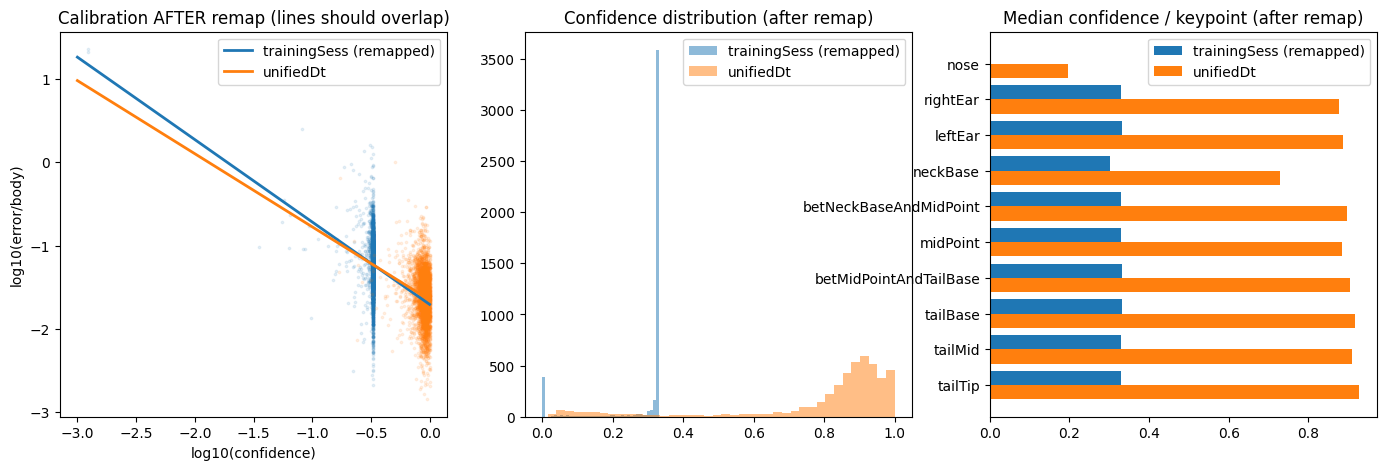

In [10]:
## Remapping the confidence keypoint predictions from the training Sessions multi-animal DLC model to the unifiedDt single-animal model 

# --- fit each model's calibration (log10 conf -> log10 error/body) --- This is the formula KPMS uses for callibration the algorithm based on the relationship between 
# predictibility error and the confidence between that predction (0 - 1)
def fit(conf, err):
    x = np.log10(conf.ravel()+EPS); y = np.log10(err.ravel()+EPS); m = np.isfinite(x)&np.isfinite(y)
    return np.polyfit(x[m], y[m], 1)
sA, iA = fit(cA, errA_n)      # trainingSess (overconfident)
sB, iB = fit(cB, errB_n)      # unifiedDt (reference)

# --- remap trainingSess confidences onto unifiedDt's scale ---
cA_remap = np.clip(10**((sA*np.log10(np.clip(cA, EPS, 1)) + iA - iB) / sB), 0, 1)
sA2, iA2 = fit(cA_remap, errA_n)     # refit AFTER remap -> should match unifiedDt

print("FIT PARAMETERS  (log10 confidence -> log10 error/body)")
print(f"  trainingSess (raw) :  slope = {sA:.4f}   intercept = {iA:.4f}")
print(f"  unifiedDt (ref)    :  slope = {sB:.4f}   intercept = {iB:.4f}")
print(f"\nREMAP:  c' = 10^(( {sA:.4f}*log10(c) + {iA:.4f} - ({iB:.4f}) ) / {sB:.4f})")
print(f"  check  conf 1.0 -> {10**((sA*np.log10(1.0)+iA-iB)/sB):.3f}")
print(f"\n  trainingSess AFTER remap:  slope = {sA2:.4f}   intercept = {iA2:.4f}   (target = unifiedDt above)")
print(f"  median confidence  trainingSess {np.nanmedian(cA):.3f} -> {np.nanmedian(cA_remap):.3f}   |  unifiedDt {np.nanmedian(cB):.3f}")

cA = cA_remap     # use remapped confidences for the panels below
summary = pd.DataFrame({"bodypart": bps,
    "errA_%body": 100*np.nanmedian(errA_n,0), "errB_%body": 100*np.nanmedian(errB_n,0),
    "confA_remap": np.nanmedian(cA,0), "confB": np.nanmedian(cB,0)})
display(summary.round(3))

# --- same 6 panels, now with remapped trainingSess confidence ---
fig, ax = plt.subplots(1, 3, figsize=(17, 5)); yy = np.arange(len(bps)); xl = np.linspace(np.log10(EPS), 0, 50)

xA,yA = np.log10(cA.ravel()+EPS), np.log10(errA_n.ravel()+EPS); mA = np.isfinite(xA)&np.isfinite(yA)
xB,yB = np.log10(cB.ravel()+EPS), np.log10(errB_n.ravel()+EPS); mB = np.isfinite(xB)&np.isfinite(yB)
ax[0].scatter(xA[mA],yA[mA],s=3,alpha=.1,color="C0"); 
ax[0].plot(xl, sA2*xl+iA2, "C0", lw=2, label="trainingSess (remapped)")
ax[0].scatter(xB[mB],yB[mB],s=3,alpha=.1,color="C1"); 
ax[0].plot(xl, sB*xl+iB, "C1", lw=2, label="unifiedDt")
ax[0].set_xlabel("log10(confidence)"); 
ax[0].set_ylabel("log10(error/body)"); 
ax[0].set_title("Calibration AFTER remap (lines should overlap)"); 
ax[0].legend()

ax[1].hist(cA.ravel(),40,alpha=.5,label="trainingSess (remapped)"); 
ax[1].hist(cB.ravel(),40,alpha=.5,label="unifiedDt")
ax[1].set_title("Confidence distribution (after remap)"); 
ax[1].legend()

ax[2].barh(yy-.2, np.nanmedian(cA,0), .4, label="trainingSess (remapped)"); 
ax[2].barh(yy+.2, np.nanmedian(cB,0), .4, label="unifiedDt")
ax[2].set_yticks(yy); 
ax[2].set_yticklabels(bps); 
ax[2].invert_yaxis(); 
ax[2].set_title("Median confidence / keypoint (after remap)"); 
ax[2].legend()


# Body size (video resolution) and confidence calibration

In [11]:
Agg = ["975826", "975827", "975833", "978772", "978774", "988590", "997838", "1010820", "1010823", "1010826", "1029741"]
nonAgg = ["975830", "978775", "1010819", "997839", "997840", "997841", "1029736", "1029739", "1032216"]
maladaptive = ["978513", "978527", "978528", "1010832", "1013590", "1034805", "1034814"]

In [12]:
import os, re, numpy as np, pandas as pd

src_dir = Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topview_DLC_singleAnimal\analyzedVideos_unifiedDataset_DLC_singleAnimal_downsampled_10fps")
dst_dir = r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topview_DLC_singleAnimal\analyzedVideos_unifiedDataset_DLC_singleAnimal_downsampled_10fps_calibrated"
os.makedirs(dst_dir, exist_ok=True)

# mice whose trainingSessions recordings need the confidence remap
remap_ids = set(Agg + nonAgg + maladaptive)
# sA, iA, sB, iB, EPS already exist from the calibration cell (not recomputed here)

files = [f for f in src_dir.rglob("*.h5")]

# ---- PASS 1: per-file body size (radius of gyration) -> global target scale ----
confThr = 0.65
scales = {}
for fp in files:
    a = pd.read_hdf(fp).to_numpy().astype(float)
    K = a.shape[1] // 3; a = a.reshape(len(a), K, 3)
    xy = np.where((a[:, :, 2] >= confThr)[:, :, None], a[:, :, :2], np.nan)   # ignore low-conf pts
    cen = np.nanmean(xy, 1, keepdims=True)
    scales[fp] = np.nanmedian(np.nanmean(np.linalg.norm(xy - cen, axis=2), 1))
TARGET = np.nanmedian(list(scales.values()))
print("target body size (px):", round(TARGET, 2))

C:\Users\stagk\AppData\Local\Temp\ipykernel_26212\544436241.py:20: RuntimeWarning: Mean of empty slice
  cen = np.nanmean(xy, 1, keepdims=True)
C:\Users\stagk\AppData\Local\Temp\ipykernel_26212\544436241.py:21: RuntimeWarning: Mean of empty slice
  scales[fp] = np.nanmedian(np.nanmean(np.linalg.norm(xy - cen, axis=2), 1))
C:\Users\stagk\AppData\Local\Temp\ipykernel_26212\544436241.py:20: RuntimeWarning: Mean of empty slice
  cen = np.nanmean(xy, 1, keepdims=True)
C:\Users\stagk\AppData\Local\Temp\ipykernel_26212\544436241.py:21: RuntimeWarning: Mean of empty slice
  scales[fp] = np.nanmedian(np.nanmean(np.linalg.norm(xy - cen, axis=2), 1))
C:\Users\stagk\AppData\Local\Temp\ipykernel_26212\544436241.py:20: RuntimeWarning: Mean of empty slice
  cen = np.nanmean(xy, 1, keepdims=True)
C:\Users\stagk\AppData\Local\Temp\ipykernel_26212\544436241.py:21: RuntimeWarning: Mean of empty slice
  scales[fp] = np.nanmedian(np.nanmean(np.linalg.norm(xy - cen, axis=2), 1))
C:\Users\stagk\AppData\Local

target body size (px): 37.01


C:\Users\stagk\AppData\Local\Temp\ipykernel_26212\544436241.py:20: RuntimeWarning: Mean of empty slice
  cen = np.nanmean(xy, 1, keepdims=True)
C:\Users\stagk\AppData\Local\Temp\ipykernel_26212\544436241.py:21: RuntimeWarning: Mean of empty slice
  scales[fp] = np.nanmedian(np.nanmean(np.linalg.norm(xy - cen, axis=2), 1))
C:\Users\stagk\AppData\Local\Temp\ipykernel_26212\544436241.py:20: RuntimeWarning: Mean of empty slice
  cen = np.nanmean(xy, 1, keepdims=True)
C:\Users\stagk\AppData\Local\Temp\ipykernel_26212\544436241.py:21: RuntimeWarning: Mean of empty slice
  scales[fp] = np.nanmedian(np.nanmean(np.linalg.norm(xy - cen, axis=2), 1))
C:\Users\stagk\AppData\Local\Temp\ipykernel_26212\544436241.py:20: RuntimeWarning: Mean of empty slice
  cen = np.nanmean(xy, 1, keepdims=True)
C:\Users\stagk\AppData\Local\Temp\ipykernel_26212\544436241.py:21: RuntimeWarning: Mean of empty slice
  scales[fp] = np.nanmedian(np.nanmean(np.linalg.norm(xy - cen, axis=2), 1))
C:\Users\stagk\AppData\Local

In [18]:
# ---- PASS 2: scale all coords to TARGET; remap confidence only where needed ----
n_remap = 0
for fp in files:
    df = pd.read_hdf(fp)
    arr = df.to_numpy().astype(float); K = arr.shape[1] // 3; a = arr.reshape(len(arr), K, 3)

    a[:, :, :2] *= TARGET / scales[fp]                          # coordinate calibration (all files)

    name = os.path.basename(fp)
    mid = re.search(r"mouse(\d+)", name); day = re.search(r"_Day(\d+)", name)
    need_remap = (mid and mid.group(1) in remap_ids and day and len(day.group(1)) == 2)
    if need_remap:                                             # 2-digit day + listed mouse = trainingSessions
        c = np.clip(a[:, :, 2], EPS, 1)
        a[:, :, 2] = np.clip(10**((sA*np.log10(c) + iA - iB) / sB), 0, 1)
        n_remap += 1

    out = pd.DataFrame(a.reshape(len(a), K*3), columns=df.columns, index=df.index)
    out.to_hdf(os.path.join(dst_dir, os.path.splitext(name)[0] + "_calibrated.h5"),
               key="df_with_missing", mode="w", format="table")

print(f"wrote {len(files)} files | confidence-remapped {n_remap}")

C:\Users\stagk\AppData\Local\Temp\ipykernel_11856\2244657627.py:20: RuntimeWarning: Mean of empty slice
  cen = np.nanmean(xy, 1, keepdims=True)
C:\Users\stagk\AppData\Local\Temp\ipykernel_11856\2244657627.py:21: RuntimeWarning: Mean of empty slice
  scales[fp] = np.nanmedian(np.nanmean(np.linalg.norm(xy - cen, axis=2), 1))
C:\Users\stagk\AppData\Local\Temp\ipykernel_11856\2244657627.py:20: RuntimeWarning: Mean of empty slice
  cen = np.nanmean(xy, 1, keepdims=True)
C:\Users\stagk\AppData\Local\Temp\ipykernel_11856\2244657627.py:21: RuntimeWarning: Mean of empty slice
  scales[fp] = np.nanmedian(np.nanmean(np.linalg.norm(xy - cen, axis=2), 1))
C:\Users\stagk\AppData\Local\Temp\ipykernel_11856\2244657627.py:20: RuntimeWarning: Mean of empty slice
  cen = np.nanmean(xy, 1, keepdims=True)
C:\Users\stagk\AppData\Local\Temp\ipykernel_11856\2244657627.py:21: RuntimeWarning: Mean of empty slice
  scales[fp] = np.nanmedian(np.nanmean(np.linalg.norm(xy - cen, axis=2), 1))
C:\Users\stagk\AppData

target body size (px): 37.01
wrote 850 files | confidence-remapped 249
